<a href="https://colab.research.google.com/github/aliya-sharif/PRO/blob/main/Step_count_analysis" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import random
import matplotlib.pyplot as plt
import statistics

random.seed(42)

In [26]:
# Organising data collected (step count) via Google form

step_count = [276, 1573, 6145, 6500, 7000, 8276, 9134, 10000, 12730, 12783,
              13000, 14530, 15000, 15045, 16000, 18000, 21417, 22459, 24842]
number_of_people = len(step_count)
print(f"{number_of_people} collegues recorded their step count.")
print()

19 collegues recorded their step count.



Average step count: 12353.157894736842
Median step count: 12783
Maximum step count: 24842
Minimum step count: 276
Saved step_count_histogram.png



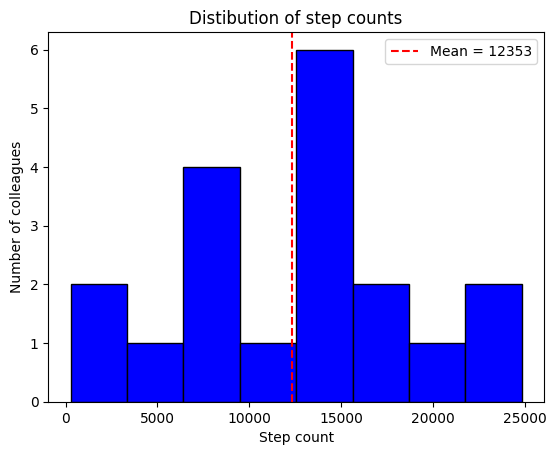

In [27]:
# Statistics
statistics.mean(step_count)
statistics.median(step_count)


print(f"Average step count: {statistics.mean(step_count)}")
print(f"Median step count: {statistics.median(step_count)}")
print(f"Maximum step count: {max(step_count)}")
print(f"Minimum step count: {min(step_count)}")

# Histogram displaying distribution of step count

fig, ax = plt.subplots()
ax.hist(step_count, bins = 8, color = "blue", edgecolor = "black")
ax.axvline(statistics.mean(step_count), color = "red", linestyle = "--", label = f"Mean = {statistics.mean(step_count):.0f}" )
ax.set_xlabel("Step count")
ax.set_ylabel("Number of colleagues")
ax.set_title("Distibution of step counts")
ax.legend()
fig.savefig("step_count_histogram", dpi = 150)
print("Saved step_count_histogram.png")
print()

In [28]:
def outliers_iqr(data):
  q1, _, q3 = statistics.quantiles(data, n=4)
  iqr = q3 - q1
  lower_bound = q1 - (iqr * 1.5)
  upper_bound = q3 + (iqr * 1.5)

  outliers_iqr = [x for x in data if x < lower_bound or x > upper_bound]
  return outliers_iqr

outliers_iqr = outliers_iqr(step_count)
print(f"Number of outliers: {len(outliers_iqr)}")
print(f"Outliers: {outliers_iqr}")

Number of outliers: 0
Outliers: []


In [29]:
# Bootstrap resampling

number_of_resamples = 10000
bootstrap_means = []
for resample_number in range(number_of_resamples):
  one_resample = random.choices(step_count, k = number_of_people)
  resample_average = statistics.mean(one_resample)
  bootstrap_means.append(resample_average)

print(f"Generated {number_of_resamples} bootstrap resamples")
print()

Generated 10000 bootstrap resamples



Bootstrap confidence interval for the average step count:
Lower bound: 9399
Upper bound: 15239 
our original average: 12353
So we are 95% confident the true average (across all hospitality workers,
 not just my 19 colleagues) lies between 9399 and 15239 

Saved bootstrap_resampling.png



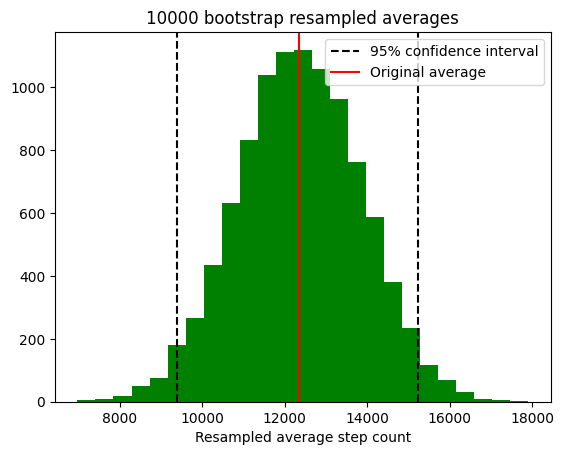

In [30]:
# Confidence Interval

def percentile(numbers, target_percentile):
  sorted_numbers = sorted(numbers)
  n = len(sorted_numbers)
  position = int((target_percentile / 100) * n)
  if position >= n:
    position = n-1
  return sorted_numbers[position]

lower_confidence_bound = percentile(bootstrap_means, 2.5)
upper_confidence_bound = percentile(bootstrap_means, 97.5)

print(f"Bootstrap confidence interval for the average step count:")
print(f"Lower bound: {lower_confidence_bound:.0f}")
print(f"Upper bound: {upper_confidence_bound:.0f} ")
print(f"our original average: {statistics.mean(step_count):.0f}")
print(f"So we are 95% confident the true average (across all hospitality workers,")
print(f" not just my 19 colleagues) lies between {lower_confidence_bound:.0f} and {upper_confidence_bound:.0f} ")
print()

fig, ax = plt.subplots()
ax.hist(bootstrap_means, bins = 25, color = "green")
ax.axvline(lower_confidence_bound, color = "black", linestyle = "--", label = "95% confidence interval")
ax.axvline(upper_confidence_bound, color = "black", linestyle = "--")
ax.axvline(statistics.mean(step_count), color = "red", label = "Original average")
ax.set_xlabel("Resampled average step count")
ax.set_title(f"{number_of_resamples} bootstrap resampled averages")
ax.legend()
fig.savefig("bootstrap_resampling.png", dpi = 300)
print("Saved bootstrap_resampling.png")
print()

In [31]:
# Historical Simulation - how low does the least active 10% go?

bottom_10_percent = percentile(step_count, 10)
print(f"HISTORICAL SIMULATION: bottom 10% of step counts = {bottom_10_percent} steps")
print(f"(10% of colleagues recorded fewer steps than this number)")
print()

# How much uncertainty does this estimate carry?

bootstrap_means_10 = []
for resample_number in range(number_of_resamples):
  one_resample = random.choices(step_count, k = number_of_people)
  resample_mean_10 = percentile(one_resample, 10)
  bootstrap_means_10.append(resample_mean_10)
lower_confidence_bound_10 = percentile(bootstrap_means_10, 2.5)
upper_confidence_bound_10 = percentile(bootstrap_means_10, 97.5)
print(f"95% confidence interval for the 10th percentile of step counts:")
print(f"Lower bound: {lower_confidence_bound_10:.0f}")
print(f"Upper bound: {upper_confidence_bound_10:.0f}")
print(f"This range is much wider than the confidence interval for the average")
print(f"with only 19 people, an extreme value is much less certain than the")
print(f"overall average. Showing how little we really know about the extremes")
print(f"from such a small sample.")

HISTORICAL SIMULATION: bottom 10% of step counts = 1573 steps
(10% of colleagues recorded fewer steps than this number)

95% confidence interval for the 10th percentile of step counts:
Lower bound: 276
Upper bound: 7000
This range is much wider than the confidence interval for the average
with only 19 people, an extreme value is much less certain than the
overall average. Showing how little we really know about the extremes
from such a small sample.
